In [22]:
import pandas as pd

In [23]:
def show_average_scores(csv_path='results/audio_quality_evaluation.csv'):
    """
    Read the CSV file and display the average value of each column.
    """
    df = pd.read_csv(csv_path)
    
    # Get numeric columns (excluding file_name and category)
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    avg_scores = df[numeric_cols].mean()
    
    print("Column averages:")
    print("=" * 50)
    for col, avg in avg_scores.items():
        print(f"{col:20s}: {avg:.4f}")
    
    return avg_scores

In [24]:
avg_scores = show_average_scores()

Column averages:
raw_ovrl            : 2.3073
raw_sig             : 2.9819
raw_bak             : 2.7290
mossformer_ovrl     : 3.0232
mossformer_sig      : 3.4136
mossformer_bak      : 4.1258
frcrn_se_ovrl       : 2.8704
frcrn_se_sig        : 3.3260
frcrn_se_bak        : 3.9332
demucs_ovrl         : 2.8157
demucs_sig          : 3.3191
demucs_bak          : 3.7655
denoiser_ovrl       : 2.9687
denoiser_sig        : 3.2946
denoiser_bak        : 4.2052
resemble_ovrl       : 2.8856
resemble_sig        : 3.3151
resemble_bak        : 3.8913


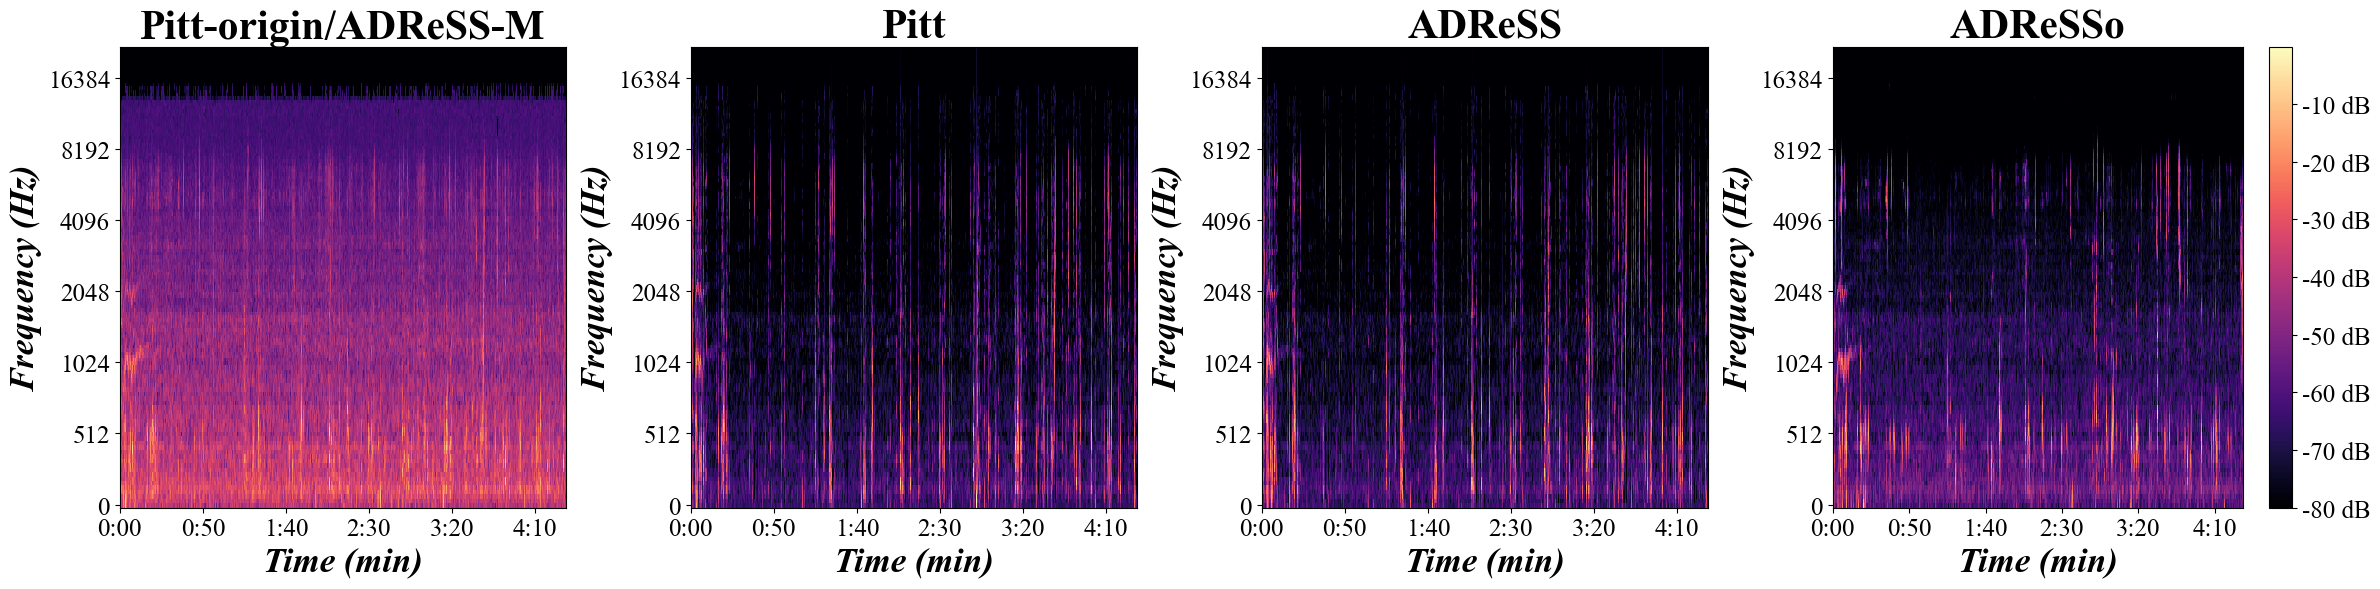

In [26]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'

# Longest-duration Dementia audio file across the five datasets (~268s)
audio_files = {
    'Pitt-origin/ADReSS-M': '../ad_detection/data/raw/Pitt-origin/Dementia/268-0.mp3',
    'Pitt': '../ad_detection/data/raw/Pitt/Dementia/268-0.wav',
    'ADReSS': '../ad_detection/data/raw/ADReSS/Dementia/S167.wav',
    'ADReSSo': '../ad_detection/data/raw/ADReSSo/Dementia/adrso056.wav',
    # 'ADReSS-M': '../ad_detection/data/raw/ADReSS-M/Dementia/adrso056.mp3',
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.15]})
axes_flat = axes.flatten()
last_idx = len(audio_files) - 1

for idx, (name, path) in enumerate(audio_files.items()):
    y, sr = librosa.load(path, sr=None)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    ax = axes_flat[idx]
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'{name}', fontsize=30, fontweight='bold')
    ax.set_xlabel('Time (min)', fontsize=25, fontweight='bold', fontstyle='italic')
    ax.set_ylabel('Frequency (Hz)', fontsize=25, fontweight='bold', fontstyle='italic')
    ax.tick_params(axis='both', labelsize=18)
    if idx == last_idx:
        cbar = fig.colorbar(img, ax=ax, format='%+2.0f dB')
        cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.savefig('results/mel_spectrogram_dementia_comparison.pdf', bbox_inches='tight')
plt.show()